In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from typing import Literal

## Libs for Agents
from langchain_community.tools import TavilySearchResults
from langchain.agents import create_agent
from langchain.tools import tool

In [3]:
class FlowState(BaseModel):
    question:str = Field(description="User Asked question")
    category: Literal["coding","web_search","weather"] = Field(default="web_search")
    answer : str = Field(default="")

In [17]:
class QuestionCategory(BaseModel):
        category: Literal["coding","web_search","weather"] = Field(default="web_search",description="question category")

In [5]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [25]:
search_tool = TavilySearchResults(search_depth="basic")

google_agent = create_agent(
    model=llm,
    tools=[search_tool],
    system_prompt="""You are a helpful assistant answering user queries.
                    1. You MUST ALWAYS use the search tool to find answers.
                    2. Treat the search tool results as ABSOLUTE FACT. 
                    3. NEVER contradict the search results. If the search results say an event in 2026 has happened, you must answer as if it has happened.
                    4. Do not rely on your internal training data or knowledge of current dates.
                """
)

@tool
def weather_agent(city:str):
    """search for the weather of given location."""

    return f"Current weather in {city} is 25.C"


weather_agent = create_agent(
    model=llm,
    tools=[weather_agent],
    system_prompt="You are an weather agent, your task is to give realtime weather of given city."
)

In [26]:
def check_question_category(state:FlowState) -> FlowState:
    stllm = llm.with_structured_output(QuestionCategory)
    res = stllm.invoke(f"Give me the category of the question, question is: {state.question} . If you are not sure abote the category return 'web_search' as default category.")
    state.category = res.category
    return state

In [27]:
def route(state:FlowState) -> Literal["coding","web_search","weather"]:
    return state.category

In [28]:
def coding_node(state:FlowState) -> FlowState:
    res = llm.invoke(f"You are an coding agent: {state.question}")
    state.answer = res.content
    return state

def web_search_node(state:FlowState) -> FlowState:
    res = google_agent.invoke({"messages":[{
        "role":"user","content":state.question
    }]})
    state.answer = res["messages"][-1].content
    return state

def weather_node(state:FlowState) -> FlowState:
    res = weather_agent.invoke({"messages":[
        {"role":"user", "content":state.question}
    ]})
    state.answer = res["messages"][-1].content
    return state



In [29]:
graph = StateGraph(FlowState)

graph.add_node("check_question_category",check_question_category)
graph.add_node("web_search",web_search_node)
graph.add_node("coding",coding_node)
graph.add_node("weather",weather_node)

graph.add_edge(START,"check_question_category")
graph.add_conditional_edges("check_question_category",route)
graph.add_edge("web_search",END)
graph.add_edge("coding",END)
graph.add_edge("weather",END)

graph = graph.compile()

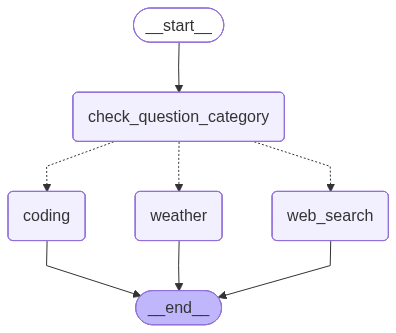

In [30]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [32]:
res = graph.invoke({"question":"who is teh winner of t20 worldcup 2026 ? also tell me the weather in mumbai"})
res

{'question': 'who is teh winner of t20 worldcup 2026 ? also tell me the weather in mumbai',
 'category': 'web_search',
 'answer': [{'type': 'text',
   'text': 'India won the T20 World Cup 2026, defeating New Zealand in the final.\n\nThe current weather in Mumbai is 32.0°C, but it feels like 42.0°C. There is mist and a wind of 19.1 kph from the West.',
   'extras': {'signature': 'CuYDAQw51seHeLy2CTOdWKWvQpGpB61czyujkrxQnr8zQu5HDIwObR2SehJ8RPDYx7dKph5ylMnn3RCVuli4O4yijJvDVsObGMYUy2u26D8Gi3RZAlNOvsvTgtCdWf/YJz67nh0DlJV6ZiGpvHeSCb2zeU++q6OLMBovzqftXCGBhxbUDs2Hnm4F5egZhCEyzBBt6c0WHBgB9dQYHXCwvkqqWAkii9qvueBbs+Fn4LWk0FrRy8xSinQ2qvPBJoukTACOKL32fL2yLUww1uBD7ROkKY9/JYpJ8AT2iVH0aIqvWKSPECsNQ348Klk8edLLhWO9k4EcXqtKM2xx0gaSFVLZ8+csxKlnFXANeC6m5tje2kIH/6W/8SbQRTB7CVl1J+/bHtNOuNrChcITlpWTLqzXd3V3H1dvAJbBxUBQZxQ0xvFDHkXFynWgkO+wDjCqH5d3Wa5A4QgFhVQTlMMzozSi3vTJEPcBPveqyypKA7nW7qzj6LT7AbNhZtRoYmaoSY195/jB6itTq73avt2o3UzaM7RTf6m3qJ+eUeYTQ9sLxT7AlM403pQcqJm3Q8BbuRS4/Jc7MpPpNdV9Q4+31k59AuDqDiwcppEWBhOS9P